# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [1]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st

In [2]:
# Recuperando o DataFrame para exportar
    # Criando o DataFrame inicial
df_genes = pd.read_csv('df_genes.csv', index_col='Unnamed: 0')
df_genes['id_entrez'] = [
    "NM_003140.3",
    "NM_004066.3",
    "XM_842234.1",
    "NM_004448.4",
    "XM_067079949.1"
]

df_genes['id_protein'] = [
    "NP_003131.1",
    "NP_004057.1",
    "XP_847327.1",
    "NP_004439.2",
    "XP_066936050.1"
]

descr_gene = {}
for gene in df_genes.index:
    caminho = f"./{gene}.fasta"
    with open(caminho, 'r') as file:
        data = file.read()
        data = data.split('\n')
        cod = data[0].split(" ")[0]
        seq = ''.join(data[1:-2])
        descr_gene[gene] = {"gene": gene, "cod": cod, "seq": seq}
df = pd.DataFrame.from_dict(descr_gene, orient='index')

    # Adicionando o DataFrame Final
fas_gene1 = {}
for aa in df.iloc[0,2]:
    fas_gene1[aa] = df.iloc[0,2].count(aa)

fas_gene2 = {}
for aa in df.iloc[0,2]:
    fas_gene2[aa] = df.iloc[1,2].count(aa)

fas_gene3 = {}
for aa in df.iloc[0,2]:
    fas_gene3[aa] = df.iloc[2,2].count(aa)

fas_gene4 = {}
for aa in df.iloc[0,2]:
    fas_gene4[aa] = df.iloc[3,2].count(aa)

fas_gene5 = {}
for aa in df.iloc[0,2]:
    fas_gene5[aa] = df.iloc[4,2].count(aa)

dic_genes = {
    "SRY": fas_gene1,
    "Cetn-1": fas_gene2,
    "PFR2": fas_gene3,
    "HER2": fas_gene4,
    "GFP": fas_gene5
}

df_aa = pd.DataFrame(dic_genes).sort_index()

    # Trocando o código do aminoácido pelo nome extenso
df_aa.index = ["Alanina", "Cisteína", "Aspartato", "Glutamato", "Fenilalanina",
               "Glicina", "Histidina", "Isoleucina", "Lisina", "Leucina",
               "Metionina", "Asparagina", "Prolina", "Glutamina", "Arginina",
               "Serina", "Treonina", "Valina", "Triptofano", "Tirosina"]
df_aa

,SRY,Cetn-1,PFR2,HER2,GFP
Alanina,15,12,53,83,17
Cisteína,6,0,7,59,5
Aspartato,9,16,34,65,13
Glutamato,12,24,79,77,13
Fenilalanina,5,10,14,35,10
Glicina,4,11,18,101,22
Histidina,5,0,18,35,8
Isoleucina,4,7,29,44,14
Lisina,15,21,59,39,16
Leucina,16,13,59,138,17


In [3]:
# Exportando o DataFrame
df_aa.to_csv('df_aa.csv')

In [4]:
# Importando o DataFrame
df_aa = pd.read_csv('df_aa.csv', index_col='Unnamed: 0')
df_aa

,SRY,Cetn-1,PFR2,HER2,GFP
Alanina,15,12,53,83,17
Cisteína,6,0,7,59,5
Aspartato,9,16,34,65,13
Glutamato,12,24,79,77,13
Fenilalanina,5,10,14,35,10
Glicina,4,11,18,101,22
Histidina,5,0,18,35,8
Isoleucina,4,7,29,44,14
Lisina,15,21,59,39,16
Leucina,16,13,59,138,17


Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [5]:
def medidor_tendcent(obj:list | tuple | pd.Series) -> list:
    '''
    Função para pegar um objeto (obj) composto unidimensional (lista, tupla ou pandas.Series)
    e retornar uma lista contendo as medidas centrais: primeiro, a média; segundo, a mediana;
    teceiro, a moda (que pode ser uma lista se houver mais de um valor)
    '''
    resultado = [
        st.mean(obj),
        st.median(obj),
        st.multimode(obj)
    ]
    return resultado

In [6]:
# ou retornando um dicionário
def medidor_tendcent(obj:list | tuple | pd.Series) -> dict:
    '''
    Função para pegar um objeto (obj) composto unidimensional (lista, tupla ou pandas.Series)
    e retornar um dicionário contendo as medidas centrais: média, mediana e a moda (que pode
    ser uma lista se houver mais de um valor)
    '''
    resultado = {
        "Média": st.mean(obj),
        "Mediana": st.median(obj),
        "Moda": st.multimode(obj)
    }
    return resultado

In [7]:
# Valor da média, mediana e moda da Serina nos genes analisados, respectivamente:
medidor_tendcent(obj=df_aa.loc["Serina"])

{'Média': 28, 'Mediana': 21, 'Moda': [21, 9, 26, 73, 11]}

In [8]:
# Valor da média, mediana e moda do terceiro gene (PFR2), respectivamente:
medidor_tendcent(obj=df_aa.iloc[:,2])

{'Média': 30, 'Mediana': 24.5, 'Moda': [18, 59]}

## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [9]:
def medidor_ampl(obj: list | tuple | pd.Series) -> int:
    '''
    Função que recebe um objeto (obj) composto unidimensional (lista, tupla ou pandas Series)
    e retorna a amplitude
    '''
    resultado = max(obj) - min(obj)
    return resultado

In [10]:
# Amplitude da Isoleucina
medidor_ampl(obj=df_aa.loc["Isoleucina"])

40

In [11]:
# Amplitude do último gene (GFP)
medidor_ampl(obj=df_aa.iloc[:,-1])

21

## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [12]:
def medidor_quar(obj: list | tuple | pd.Series) -> list:
    '''
    Função para retornar de um objeto composto unidimensional (lista, tupla ou pandas.Series)
    o valor de Q1, Q2 e Q3, respectivamente
    '''
    quantil_1 = np.quantile(obj, [0.25])
    quantil_2 = np.quantile(obj, [0.5])
    quantil_3 = np.quantile(obj, [0.75])
    resultado = float(quantil_1[0]), float(quantil_2[0]), float(quantil_3[0])
    return resultado

In [13]:
# Q1, Q2 e Q3 da Metionina, respectivamente
medidor_quar(obj=df_aa.loc["Metionina"])

(8.0, 9.0, 19.0)

In [14]:
# Q1, Q2 e Q3 do primeiro gene (SRY), respectivamente
medidor_quar(obj=df_aa.iloc[:,0])

(5.75, 9.0, 14.25)

## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [15]:
def medidor_iquar(obj: list | tuple | pd.Series) -> list:
    '''
    Função para retornar de um objeto composto unidimensional (lista, tupla ou pandas.Series)
    o intervalo interquartil (Q3 - Q1)
    '''
    quantil_1 = np.quantile(obj, [0.25])
    quantil_3 = np.quantile(obj, [0.75])
    resultado = float(quantil_3[0]) - float(quantil_1[0])
    return resultado

In [16]:
# Intervalo interquartil do Ácido Glutâmico (Glutamato)
medidor_iquar(obj=df_aa.loc["Glutamato"])

64.0

In [17]:
# Intervalo interquartil do penúltimo gene (HER2)
medidor_iquar(obj=df_aa.iloc[:,-2])

40.5

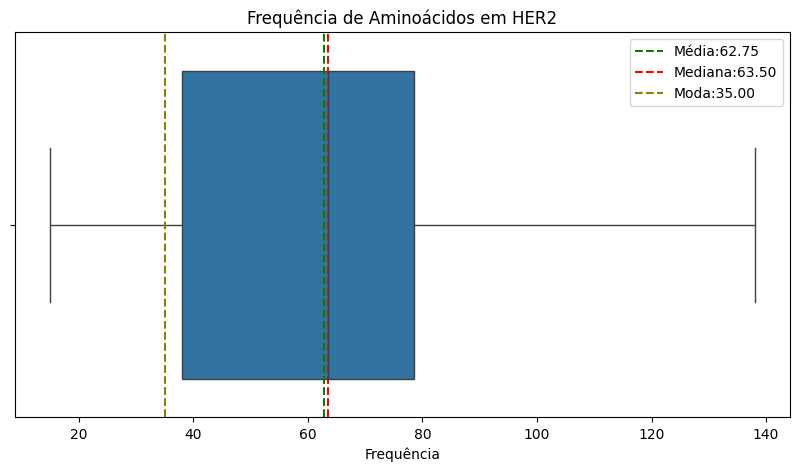

In [45]:
med_cent = medidor_tendcent(obj=df_aa["HER2"])
moda = med_cent["Moda"]

plt.figure(figsize=(10,5))
sns.boxplot(
    data = df_aa,
    x = "HER2"
)
plt.axvline(med_cent["Média"], color="green", linestyle="--", label=f'Média:{med_cent["Média"]:.2f}')
plt.axvline(med_cent["Mediana"], color="red", linestyle="--", label=f'Mediana:{med_cent["Mediana"]:.2f}')
plt.axvline(moda[0], color="#8B8000", linestyle="--", label=f'Moda:{moda[0]:.2f}')
plt.legend()
plt.title("Frequência de Aminoácidos em HER2")
plt.xlabel("Frequência")
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [19]:
def medidor_var_nv(obj:list | tuple | pd.Series) -> float:
    '''
    Função que a partir de um objeto composto unidimensional (lista, tupla ou pandas.Series),
    determinado pelo parâmetro obj, retorna a sua variância amostral não viciada
    '''
    media = st.mean(obj)
    dif_xm = []
    for n, x in enumerate(obj):
        dif_xm.append((x-media)**2)
    dif_sum = sum(dif_xm)
    resultado = dif_sum/(n) # Como n começa no 0, não precisa fazer n-1 para não viciada
    return resultado

In [20]:
# Variância amostral não viciada da Prolina
medidor_var_nv(obj=df_aa.loc["Prolina"])

2010.5

In [21]:
# Variância amostral não viciada do terceiro gene (PFR2)
medidor_var_nv(obj=df_aa.iloc[:, 2])

402.63157894736844

## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [22]:
def medidor_sd_nv(obj:list | tuple | pd.Series) -> float:
    '''
    Função que a partir de um objeto composto unidimensional (lista, tupla ou pandas.Series),
    determinado pelo parâmetro obj, retorna o seu desvio padrão amostral não viciado
    '''
    media = st.mean(obj)
    dif_xm = []
    for n, x in enumerate(obj):
        dif_xm.append((x-media)**2)
    dif_sum = sum(dif_xm)
    var_nv = dif_sum/(n)
    resultado = var_nv**0.5
    return resultado

In [23]:
# Ou
def medidor_sd_nv_alt(obj_1:list | tuple | pd.Series) -> float:
    '''
    Função que a partir de um objeto composto unidimensional (lista, tupla ou pandas.Series),
    determinado pelo parâmetro obj, retorna o seu desvio padrão amostral não viciado
    '''
    resultado = medidor_var_nv(obj=obj_1)**0.5
    return resultado

In [24]:
# Desvio padrão amostral não viciado do Triptofano
medidor_sd_nv(obj=df_aa.loc["Triptofano"])

6.024948132556828

In [25]:
# Desvio padrão amostral não viciado do último gene (GFP)
medidor_sd_nv(obj=df_aa.iloc[:, -1])

5.205260497045779

## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [26]:
def medidor_cv_nv(dado: list | tuple | pd.Series) -> float:
    '''
    Função que a partir de um objeto composto unidimensional (lista, tupla ou pandas.Series),
    determinado pelo parâmetro obj, retorna o seu desvio padrão amostral não viciado
    '''
    cv_raz = medidor_sd_nv(obj=dado)/st.mean(dado)
    resultado = cv_raz*100
    return resultado

In [27]:
# CV da leucina
medidor_cv_nv(dado=df_aa.loc["Leucina"])

109.98707468951505

In [28]:
# CV do gene de index 1 (segundo gene = Cetn-1)
medidor_cv_nv(dado=df_aa.iloc[:,1])

76.14655474585909

## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [29]:
def medidor_resumo(amostra: list | tuple | pd.Series) -> dict:
    '''
    Função que, a partir de um objeto composto unidimensional (lista, tupla ou pandas.Series),
    retorna um dicionário das medidas resumos: Média aritmética, Mediana (Q2), Moda, Amplitude,
    Q1, Q3, Intervalo Interquartil, Variância Amostral Não Viciada, Desvio Padrão e Coeficiente
    de Variação
    '''
    tendcent = medidor_tendcent(obj=amostra)
    quartis = medidor_quar(obj=amostra)
    resultado = {
        "Média": tendcent["Média"],
        "Mediana": tendcent["Mediana"],                         # Que também é o Q2
        "Moda": tendcent["Moda"],
        "Amplitude": medidor_ampl(obj=amostra),
        "Q1": quartis[0],
        "Q3": quartis[2],
        "Interquartil": medidor_iquar(obj=amostra),
        "Variância": medidor_var_nv(obj=amostra),               # Amostral Não Viciada
        "Desvio Padrão": medidor_sd_nv(obj=amostra),            # Amostral Não Viciado
        "Coeficiente de Variação": medidor_cv_nv(dado=amostra)
}
    return resultado

In [30]:
# Testando a função
medidor_resumo(amostra=df_aa.loc["Serina"])

{'Média': 28,
 'Mediana': 21,
 'Moda': [21, 9, 26, 73, 11],
 'Amplitude': 64,
 'Q1': 11.0,
 'Q3': 26.0,
 'Interquartil': 15.0,
 'Variância': 682.0,
 'Desvio Padrão': 26.115129714401192,
 'Coeficiente de Variação': 93.26832040857569}

In [31]:
# Testando a função
medidor_resumo(amostra=df_aa["GFP"])

{'Média': 11.6,
 'Mediana': 12.0,
 'Moda': [17, 5, 13, 8, 12],
 'Amplitude': 21,
 'Q1': 8.0,
 'Q3': 15.25,
 'Interquartil': 7.25,
 'Variância': 27.094736842105267,
 'Desvio Padrão': 5.205260497045779,
 'Coeficiente de Variação': 44.87293531936017}

In [32]:
# Testando a função
lista = [0, 1, 1, 1, 2, 3, 4, 4]
medidor_resumo(amostra=lista)

{'Média': 2,
 'Mediana': 1.5,
 'Moda': [1],
 'Amplitude': 4,
 'Q1': 1.0,
 'Q3': 3.25,
 'Interquartil': 2.25,
 'Variância': 2.2857142857142856,
 'Desvio Padrão': 1.5118578920369088,
 'Coeficiente de Variação': 75.59289460184544}

In [33]:
# Testando a função
tupla = (0, 1, 1, 1, 2, 3, 4, 4)
medidor_resumo(amostra=tupla)

{'Média': 2,
 'Mediana': 1.5,
 'Moda': [1],
 'Amplitude': 4,
 'Q1': 1.0,
 'Q3': 3.25,
 'Interquartil': 2.25,
 'Variância': 2.2857142857142856,
 'Desvio Padrão': 1.5118578920369088,
 'Coeficiente de Variação': 75.59289460184544}

## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [34]:
def medidor_gCVmaior(obj:pd.DataFrame) -> str:
    '''
    Função que a partir de um objeto da classe pandas.DataFrame retorna qual a coluna que possui
    o maior coeficiente de variância
    '''
    x = 0
    cv = {}
    while x < len(obj.columns):
        cv[obj.columns[x]] = medidor_cv_nv(dado=obj.iloc[:,x])
        x=x+1
    resultado = max(cv, key=cv.get)
    return resultado

In [35]:
# Testando função
medidor_gCVmaior(obj=df_aa)

'Cetn-1'

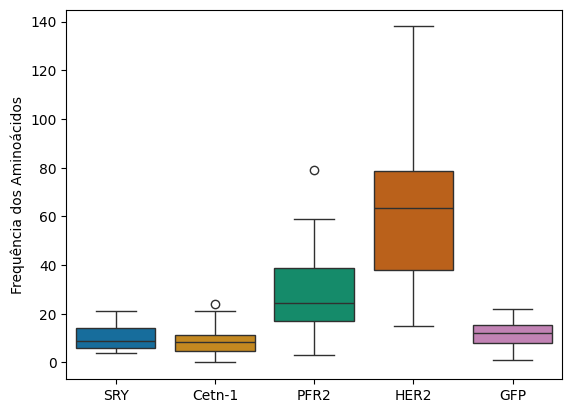

In [36]:
sns.boxplot(
    data=df_aa,
    palette="colorblind"
)
plt.ylabel("Frequência dos Aminoácidos")
plt.show()

R.: <br>
Quando é observado que o maior CV da frequência de aminoácidos ocorre em Cetn-1 e se compara com o gráfico, parece haver uma discordância; uma vez que HER2 apresenta um maior boxplot (maior distribuição dos valores). Contudo, estas discrepâncias têm relação com a forma que CV é calculada e como o gráfico é plotado. <br>
CV é calculada pela razão entre o desvio padrão e a média. Embora ambos sejam bastante influenciados por valores extremos, o desvio padrão vai ser mais influenciado do que a média, uma vez que envolve a soma dos quadrados das diferenças de cada valor em relação à média. O fato destes valores serem elevados ao quadrado (mesmo que depois o desvio seja a raíz quadrada da variância), faz com que os valores extremos aumentem proporcionalmente mais o desvio do que aumentam a média. Logo, quanto mais valores extremos existirem em relação ao resto da distribuição, maior será o desvio padrão comparado à média, o resultado da divisão entre eles, e o CV obtido. <br>
Em comparação, o boxplot é moldado de acordo com os quantis (divisão dos dados em partes iguais), havendo menor influência de valores extremos (é moldado com maior influência pelo percentual de distribuição dos valores). Se estes valores estiverem mais bem distribuídos (fazendo com que o boxplot apareça maior por resultar em maiores intervalo interquartil e limites inferiores e superiores absolutos), os mesmos valores extremos serão proporcionalmente menos influentes (são menos "intensos" em relação ao resto). <br>
Como exemplo, o valor 60 resultará em maior desvio padrão relativo à média (maior CV) em uma lista contendo [0, 1, 2, 3, 4, 5] do que em uma com [0, 10, 20, 30, 40, 50]. O desvio de ambas as listas é similar (em torno de 21), mas proporcionalmente em relação a média o da lista 1 se torna muito maior (CV igual a 203 em vez de 72 na lista 2). Em compensação, o intervalo interquartil da lista 1 é menor (3) do que da lista 2 (30). Ao observar ambas as listas em um mesmo gráfico, o boxplot da lista 1 parecerá menor do que da lista 2, como se tivesse menor distribuição, ainda que seu CV seja muito maior. <br>
O mesmo pode ser observado para Cetn-1 e HER2. Apesar que em termos absoluto o desvio padrão de HER2 (30.8) seja maior que Cetn-1 (6.5), proporcionalmente em relação à média há menor diferença (média de HER2 é 62.8 e de Cetn-1 8.6). Isso resulta em maior CV de Cetn-1 (76.1) do que HER2 (49.1). Ao observar o intervalo interquartil, no entanto; Cetn-1 é igual a 6.5 e HER2 40.5.

In [37]:
lista_1 = [0,1,2,3,4,5,60]
lista_2 = [0,10,20,30,40,50,60]
print(
    "Lista 1 =", st.mean(lista_1), medidor_sd_nv(obj=lista_1), medidor_cv_nv(dado=lista_1),
    medidor_quar(obj=lista_1), medidor_iquar(obj=lista_1), "\n",
    "Lista 2 =", st.mean(lista_2), medidor_sd_nv(obj=lista_2), medidor_cv_nv(dado=lista_2),
    medidor_quar(obj=lista_2), medidor_iquar(obj=lista_2)
)

Lista 1 = 10.714285714285714 21.799956312756574 203.46625891906137 (1.5, 3.0, 4.5) 3.0 
 Lista 2 = 30 21.602468994692867 72.00822998230956 (15.0, 30.0, 45.0) 30.0


In [38]:
for key, x in enumerate(df_aa.columns):
    print(df_aa.columns[key], medidor_resumo(amostra=df_aa[x]))

SRY {'Média': 10.2, 'Mediana': 9.0, 'Moda': [9, 4], 'Amplitude': 17, 'Q1': 5.75, 'Q3': 14.25, 'Interquartil': 8.5, 'Variância': 26.589473684210528, 'Desvio Padrão': 5.156498199767991, 'Coeficiente de Variação': 50.55390391929403}
Cetn-1 {'Média': 8.6, 'Mediana': 8.5, 'Moda': [0, 9], 'Amplitude': 24, 'Q1': 4.75, 'Q3': 11.25, 'Interquartil': 6.5, 'Variância': 42.88421052631579, 'Desvio Padrão': 6.548603708143881, 'Coeficiente de Variação': 76.14655474585909}
PFR2 {'Média': 30, 'Mediana': 24.5, 'Moda': [18, 59], 'Amplitude': 76, 'Q1': 17.0, 'Q3': 39.0, 'Interquartil': 22.0, 'Variância': 402.63157894736844, 'Desvio Padrão': 20.06568162179816, 'Coeficiente de Variação': 66.88560540599386}
HER2 {'Média': 62.75, 'Mediana': 63.5, 'Moda': [35], 'Amplitude': 123, 'Q1': 38.0, 'Q3': 78.5, 'Interquartil': 40.5, 'Variância': 950.4078947368421, 'Desvio Padrão': 30.828686231119907, 'Coeficiente de Variação': 49.12938044799985}
GFP {'Média': 11.6, 'Mediana': 12.0, 'Moda': [17, 5, 13, 8, 12], 'Amplitude

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [39]:
def medidor_aaCVmaior(obj:pd.DataFrame) -> str:
    '''
    Função que a partir de um objeto da classe pandas.DataFrame retorna qual a linha que possui
    o maior coeficiente de variância
    '''
    x = 0
    cv = {}
    while x < len(obj.index):
        cv[obj.index[x]] = medidor_cv_nv(dado=obj.iloc[x,:])
        x=x+1
    resultado = max(cv, key=cv.get)
    return resultado

In [40]:
# Testando função
medidor_aaCVmaior(obj=df_aa)

'Cisteína'

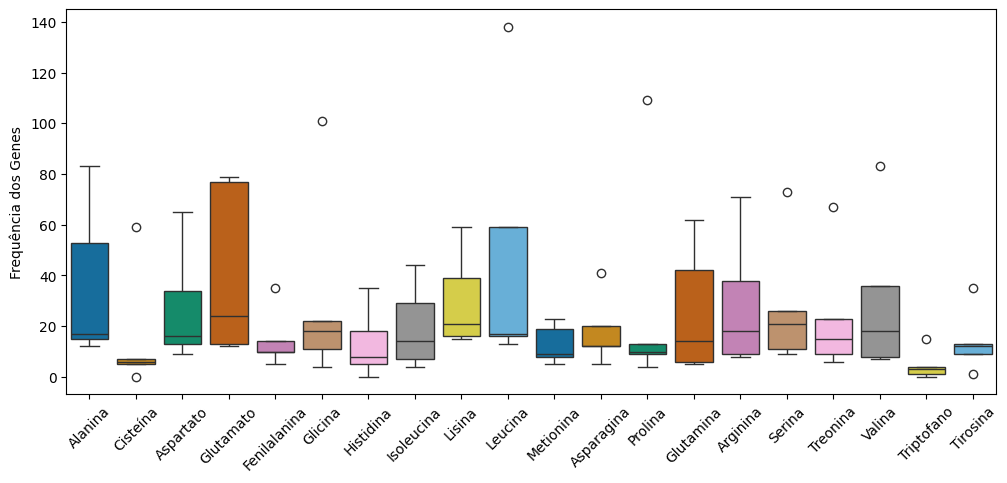

In [41]:
plt.figure(figsize=(12,5))
sns.boxplot(
    data=df_aa.transpose(),
    palette="colorblind"
)
plt.ylabel("Frequência dos Genes")
plt.xticks(rotation=45)
plt.show()

R.: <br>
Similar ao que ocorre com o boxplot de frequência de aminoácidos, quando é observado que o maior CV da frequência em genes ocorre em cisteína e se compara com o gráfico, parece haver uma discordância; uma vez que alanina e glutamato apresentam um maior boxplot (maior distribuição dos valores). Contudo, estas discrepâncias novamente têm relação com a forma que CV é calculada e como o gráfico é plotado. <br>
CV é calculada pela razão entre o desvio padrão e a média. Embora ambos sejam bastante influenciados por valores extremos, o desvio padrão vai ser mais influenciado do que a média, uma vez que envolve a soma dos quadrados das diferenças de cada valor em relação à média. O fato destes valores serem elevados ao quadrado (mesmo que depois o desvio seja a raíz quadrada da variância), faz com que os valores extremos aumentem proporcionalmente mais o desvio do que aumentam a média. Logo, quanto mais valores extremos existirem em relação ao resto da distribuição, maior será o desvio padrão comparado à média, o resultado da divisão entre eles, e o CV obtido. <br>
Em comparação, o boxplot é moldado de acordo com os quantis (divisão dos dados em partes iguais), havendo menor influência de valores extremos (é moldado com maior influência pelo percentual de distribuição dos valores). Se estes valores estiverem mais bem distribuídos (fazendo com que o boxplot apareça maior por resultar em maiores intervalo interquartil e limites inferiores e superiores absolutos), os mesmos valores extremos serão proporcionalmente menos influentes (são menos "intensos" em relação ao resto). <br>
Como exemplo, o valor 60 resultará em maior desvio padrão relativo à média (maior CV) em uma lista contendo [0, 1, 2, 3, 4, 5] do que em uma com [0, 10, 20, 30, 40, 50]. O desvio de ambas as listas é similar (em torno de 21), mas proporcionalmente em relação a média o da lista 1 se torna muito maior (CV igual a 203 em vez de 72 na lista 2). Em compensação, o intervalo interquartil da lista 1 é menor (3) do que da lista 2 (30). Ao observar ambas as listas em um mesmo gráfico, o boxplot da lista 1 parecerá menor do que da lista 2, como se tivesse menor distribuição, ainda que seu CV seja muito maior. <br>
O mesmo pode ser observado para cisteína, alanina e glutamato. Apesar que em termos absoluto o desvio padrão da alanina (31.1) e glutamato (34.1) seja maiores que de cisteína (24.5), proporcionalmente em relação à média há menor diferença (média de alanina é 36.0, de glutamato 41.0 e de cisteína 15.4). Isso resulta em maior CV de cisteína (159.2) do que alanina (86.5) e glutamato (83.2). Ao observar o intervalo interquartil, no entanto; cisteína é igual a 2.0, alanina 38.0 e glutamato 64.0.

In [42]:
lista_1 = [0,1,2,3,4,5,60]
lista_2 = [0,10,20,30,40,50,60]
print(
    "Lista 1 =", st.mean(lista_1), medidor_sd_nv(obj=lista_1), medidor_cv_nv(dado=lista_1),
    medidor_quar(obj=lista_1), medidor_iquar(obj=lista_1), "\n",
    "Lista 2 =", st.mean(lista_2), medidor_sd_nv(obj=lista_2), medidor_cv_nv(dado=lista_2),
    medidor_quar(obj=lista_2), medidor_iquar(obj=lista_2)
)

Lista 1 = 10.714285714285714 21.799956312756574 203.46625891906137 (1.5, 3.0, 4.5) 3.0 
 Lista 2 = 30 21.602468994692867 72.00822998230956 (15.0, 30.0, 45.0) 30.0


In [43]:
for key, x in enumerate(df_aa.index):
    print(df_aa.index[key], medidor_resumo(amostra=df_aa.transpose()[x]))

Alanina {'Média': 36, 'Mediana': 17, 'Moda': [15, 12, 53, 83, 17], 'Amplitude': 71, 'Q1': 15.0, 'Q3': 53.0, 'Interquartil': 38.0, 'Variância': 969.0, 'Desvio Padrão': 31.12876483254676, 'Coeficiente de Variação': 86.46879120151878}
Cisteína {'Média': 15.4, 'Mediana': 6, 'Moda': [6, 0, 7, 59, 5], 'Amplitude': 59, 'Q1': 5.0, 'Q3': 7.0, 'Interquartil': 2.0, 'Variância': 601.3, 'Desvio Padrão': 24.521419208520538, 'Coeficiente de Variação': 159.22999486052296}
Aspartato {'Média': 27.4, 'Mediana': 16, 'Moda': [9, 16, 34, 65, 13], 'Amplitude': 56, 'Q1': 13.0, 'Q3': 34.0, 'Interquartil': 21.0, 'Variância': 533.3000000000001, 'Desvio Padrão': 23.09328906847182, 'Coeficiente de Variação': 84.28207689223292}
Glutamato {'Média': 41, 'Mediana': 24, 'Moda': [12, 24, 79, 77, 13], 'Amplitude': 67, 'Q1': 13.0, 'Q3': 77.0, 'Interquartil': 64.0, 'Variância': 1163.5, 'Desvio Padrão': 34.11011580162108, 'Coeficiente de Variação': 83.19540439419775}
Fenilalanina {'Média': 14.8, 'Mediana': 10, 'Moda': [10],